In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("accidents_weather_ca_merged.csv")
df.head()

,Start_Lat,Start_Lng,Start_Time,Severity,lat,lon,weather_main,weather_desc,temp_f,humidity,visibility,wind_speed,rain_1h
0,38.362831,-122.267197,2016-12-09 05:25:36,2,38.362831,-122.267197,Clear,clear sky,60.03,77,10000,6.91,0
1,34.022625,-118.156616,2016-07-12 10:55:04,2,34.022625,-118.156616,Clear,clear sky,65.93,40,10000,4.61,0
2,38.254620,-122.335907,2016-06-06 11:20:16,2,38.254620,-122.335907,Clear,clear sky,60.04,76,10000,6.91,0
3,38.003071,-121.337051,2016-12-17 09:25:08,2,38.003071,-121.337051,Clear,clear sky,58.32,78,10000,9.22,0
4,37.403236,-122.046913,2016-11-04 11:01:44,2,37.403236,-122.046913,Clear,clear sky,60.51,72,10000,8.05,0


In [ ]:

df["Temp_Level"] = pd.cut(
    df["temp_f"],
    bins=3,
    labels=["Low_Temp", "Medium_Temp", "High_Temp"]
)

df["Visibility_Level"] = pd.cut(
    df["visibility"],
    bins=3,
    labels=["Low_Visibility", "Medium_Visibility", "High_Visibility"]
)

df["Wind_Level"] = pd.cut(
    df["wind_speed"],
    bins=3,
    labels=["Low_Wind", "Medium_Wind", "High_Wind"]
)

df["Severity_Label"] = "Severity_" + df["Severity"].astype(str)

df.head()

,Start_Lat,Start_Lng,Start_Time,Severity,lat,lon,weather_main,weather_desc,temp_f,humidity,visibility,wind_speed,rain_1h,Temp_Level,Visibility_Level,Wind_Level,Severity_Label
0,38.362831,-122.267197,2016-12-09 05:25:36,2,38.362831,-122.267197,Clear,clear sky,60.03,77,10000,6.91,0,High_Temp,Medium_Visibility,Medium_Wind,Severity_2
1,34.022625,-118.156616,2016-07-12 10:55:04,2,34.022625,-118.156616,Clear,clear sky,65.93,40,10000,4.61,0,High_Temp,Medium_Visibility,Low_Wind,Severity_2
2,38.254620,-122.335907,2016-06-06 11:20:16,2,38.254620,-122.335907,Clear,clear sky,60.04,76,10000,6.91,0,High_Temp,Medium_Visibility,Medium_Wind,Severity_2
3,38.003071,-121.337051,2016-12-17 09:25:08,2,38.003071,-121.337051,Clear,clear sky,58.32,78,10000,9.22,0,Medium_Temp,Medium_Visibility,Medium_Wind,Severity_2
4,37.403236,-122.046913,2016-11-04 11:01:44,2,37.403236,-122.046913,Clear,clear sky,60.51,72,10000,8.05,0,High_Temp,Medium_Visibility,Medium_Wind,Severity_2


In [3]:
transactions = df[[
    "Severity_Label",
    "Temp_Level",
    "Visibility_Level",
    "Wind_Level",
    "weather_main"
]].astype(str)

transactions.head()

,Severity_Label,Temp_Level,Visibility_Level,Wind_Level,weather_main
0,Severity_2,High_Temp,Medium_Visibility,Medium_Wind,Clear
1,Severity_2,High_Temp,Medium_Visibility,Low_Wind,Clear
2,Severity_2,High_Temp,Medium_Visibility,Medium_Wind,Clear
3,Severity_2,Medium_Temp,Medium_Visibility,Medium_Wind,Clear
4,Severity_2,High_Temp,Medium_Visibility,Medium_Wind,Clear


In [4]:
transactions.to_csv("arm_transactions_sample.csv", index=False)

In [5]:
import pandas as pd

transactions = pd.read_csv("arm_transactions_sample.csv")
transactions.head()

,Severity_Label,Temp_Level,Visibility_Level,Wind_Level,weather_main
0,Severity_2,High_Temp,Medium_Visibility,Medium_Wind,Clear
1,Severity_2,High_Temp,Medium_Visibility,Low_Wind,Clear
2,Severity_2,High_Temp,Medium_Visibility,Medium_Wind,Clear
3,Severity_2,Medium_Temp,Medium_Visibility,Medium_Wind,Clear
4,Severity_2,High_Temp,Medium_Visibility,Medium_Wind,Clear


In [ ]:
from mlxtend.preprocessing import TransactionEncoder

transaction_list = transactions.values.tolist()

te = TransactionEncoder()
te_array = te.fit(transaction_list).transform(transaction_list)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

df_encoded.head()

,Clear,Clouds,High_Temp,High_Wind,Low_Temp,Low_Wind,Medium_Temp,Medium_Visibility,Medium_Wind,Severity_2,Severity_3,Severity_4,Smoke
0,True,False,True,False,False,False,False,True,True,True,False,False,False
1,True,False,True,False,False,True,False,True,False,True,False,False,False
2,True,False,True,False,False,False,False,True,True,True,False,False,False
3,True,False,False,False,False,False,True,True,True,True,False,False,False
4,True,False,True,False,False,False,False,True,True,True,False,False,False


In [7]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    df_encoded,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets.sort_values(by="support", ascending=False).head()

,support,itemsets
6,1.000,(Medium_Visibility)
2,0.640,(High_Temp)
26,0.640,"(Medium_Visibility, High_Temp)"
42,0.616,"(Medium_Visibility, Severity_2)"
8,0.616,(Severity_2)


In [8]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules.head()

C:\Users\cheta\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Clear),(High_Temp),0.606,0.640,0.308,0.508251,0.794142,1.0,-0.079840,0.732081,-0.396835,0.328358,-0.365970,0.494750
1,(High_Wind),(Clear),0.140,0.606,0.132,0.942857,1.555870,1.0,0.047160,6.895000,0.415433,0.214984,0.854967,0.580339
2,(Low_Wind),(Clear),0.342,0.606,0.228,0.666667,1.100110,1.0,0.020748,1.182000,0.138298,0.316667,0.153976,0.521452
3,(Medium_Temp),(Clear),0.348,0.606,0.288,0.827586,1.365654,1.0,0.077112,2.285200,0.410660,0.432432,0.562402,0.651417
4,(Clear),(Medium_Visibility),0.606,1.000,0.606,1.000000,1.000000,1.0,0.000000,inf,0.000000,0.606000,0.000000,0.803000


In [9]:
top_support = rules.sort_values(by="support", ascending=False).head(15)
top_support

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15,(High_Temp),(Medium_Visibility),0.640,1.000,0.640,1.000000,1.000000,1.0,0.000000,inf,0.000000,0.640000,0.000000,0.820000
14,(Medium_Visibility),(High_Temp),1.000,0.640,0.640,0.640000,1.000000,1.0,0.000000,1.00000,0.000000,0.640000,0.000000,0.820000
31,(Severity_2),(Medium_Visibility),0.616,1.000,0.616,1.000000,1.000000,1.0,0.000000,inf,0.000000,0.616000,0.000000,0.808000
30,(Medium_Visibility),(Severity_2),1.000,0.616,0.616,0.616000,1.000000,1.0,0.000000,1.00000,0.000000,0.616000,0.000000,0.808000
5,(Medium_Visibility),(Clear),1.000,0.606,0.606,0.606000,1.000000,1.0,0.000000,1.00000,0.000000,0.606000,0.000000,0.803000
4,(Clear),(Medium_Visibility),0.606,1.000,0.606,1.000000,1.000000,1.0,0.000000,inf,0.000000,0.606000,0.000000,0.803000
28,(Medium_Visibility),(Medium_Wind),1.000,0.518,0.518,0.518000,1.000000,1.0,0.000000,1.00000,0.000000,0.518000,0.000000,0.759000
29,(Medium_Wind),(Medium_Visibility),0.518,1.000,0.518,1.000000,1.000000,1.0,0.000000,inf,0.000000,0.518000,0.000000,0.759000
76,(Severity_2),"(Clear, Medium_Visibility)",0.616,0.606,0.404,0.655844,1.082251,1.0,0.030704,1.14483,0.197917,0.493888,0.126508,0.661255
73,"(Clear, Medium_Visibility)",(Severity_2),0.606,0.616,0.404,0.666667,1.082251,1.0,0.030704,1.15200,0.192893,0.493888,0.131944,0.661255


In [10]:
top_confidence = rules.sort_values(by="confidence", ascending=False).head(15)
top_confidence

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
382,"(Severity_2, Clouds, High_Temp, Low_Wind)",(Medium_Visibility),0.060,1.0,0.060,1.0,1.0,1.0,0.0,inf,0.0,0.060,0.0,0.530
375,"(Clear, Medium_Temp, Severity_2, Medium_Wind)",(Medium_Visibility),0.062,1.0,0.062,1.0,1.0,1.0,0.0,inf,0.0,0.062,0.0,0.531
29,(Medium_Wind),(Medium_Visibility),0.518,1.0,0.518,1.0,1.0,1.0,0.0,inf,0.0,0.518,0.0,0.759
31,(Severity_2),(Medium_Visibility),0.616,1.0,0.616,1.0,1.0,1.0,0.0,inf,0.0,0.616,0.0,0.808
24,(Low_Wind),(Medium_Visibility),0.342,1.0,0.342,1.0,1.0,1.0,0.0,inf,0.0,0.342,0.0,0.671
26,(Medium_Temp),(Medium_Visibility),0.348,1.0,0.348,1.0,1.0,1.0,0.0,inf,0.0,0.348,0.0,0.674
342,"(Clear, Severity_2, High_Temp, Medium_Wind)",(Medium_Visibility),0.112,1.0,0.112,1.0,1.0,1.0,0.0,inf,0.0,0.112,0.0,0.556
351,"(Clear, High_Wind, Medium_Temp, Severity_2)",(Medium_Visibility),0.076,1.0,0.076,1.0,1.0,1.0,0.0,inf,0.0,0.076,0.0,0.538
22,(High_Wind),(Medium_Visibility),0.140,1.0,0.140,1.0,1.0,1.0,0.0,inf,0.0,0.140,0.0,0.570
366,"(Clear, Medium_Temp, Low_Wind, Severity_3)",(Medium_Visibility),0.052,1.0,0.052,1.0,1.0,1.0,0.0,inf,0.0,0.052,0.0,0.526


In [11]:
top_lift = rules.sort_values(by="lift", ascending=False).head(15)
top_lift

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
362,"(Medium_Visibility, High_Wind)","(Clear, Medium_Temp, Severity_2)",0.140,0.184,0.076,0.542857,2.950311,1.0,0.050240,1.785000,0.768666,0.306452,0.439776,0.477950
364,(High_Wind),"(Clear, Medium_Temp, Medium_Visibility, Severi...",0.140,0.184,0.076,0.542857,2.950311,1.0,0.050240,1.785000,0.768666,0.306452,0.439776,0.477950
199,(High_Wind),"(Clear, Severity_2, Medium_Temp)",0.140,0.184,0.076,0.542857,2.950311,1.0,0.050240,1.785000,0.768666,0.306452,0.439776,0.477950
360,"(Clear, High_Wind)","(Medium_Visibility, Medium_Temp, Severity_2)",0.132,0.228,0.076,0.575758,2.525253,1.0,0.045904,1.819714,0.695853,0.267606,0.450463,0.454545
196,"(Clear, High_Wind)","(Severity_2, Medium_Temp)",0.132,0.228,0.076,0.575758,2.525253,1.0,0.045904,1.819714,0.695853,0.267606,0.450463,0.454545
355,"(Clear, High_Wind, Medium_Visibility)","(Medium_Temp, Severity_2)",0.132,0.228,0.076,0.575758,2.525253,1.0,0.045904,1.819714,0.695853,0.267606,0.450463,0.454545
321,(High_Wind),"(Medium_Visibility, Severity_2, Medium_Temp)",0.140,0.228,0.078,0.557143,2.443609,1.0,0.046080,1.743226,0.686941,0.268966,0.426351,0.449624
318,"(Medium_Visibility, High_Wind)","(Severity_2, Medium_Temp)",0.140,0.228,0.078,0.557143,2.443609,1.0,0.046080,1.743226,0.686941,0.268966,0.426351,0.449624
137,(High_Wind),"(Severity_2, Medium_Temp)",0.140,0.228,0.078,0.557143,2.443609,1.0,0.046080,1.743226,0.686941,0.268966,0.426351,0.449624
197,"(Severity_2, High_Wind)","(Clear, Medium_Temp)",0.108,0.288,0.076,0.703704,2.443416,1.0,0.044896,2.403000,0.662261,0.237500,0.583854,0.483796


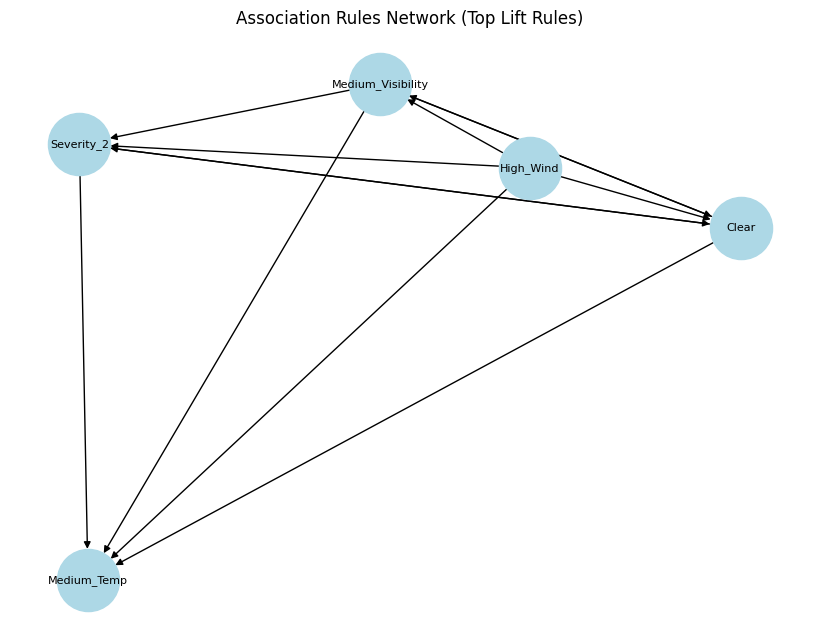

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

top_rules = top_lift.head(10)

G = nx.DiGraph()

for _, row in top_rules.iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'])

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_size=8)
plt.title("Association Rules Network (Top Lift Rules)")
plt.show()

In [13]:
rules.to_csv("arm_rules_results.csv", index=False)